# Correlation Analysis & Feature Importance

**Week 3 - Task A**  
**Author:** Pratik   
**Date:** February 2026

## Objectives
1. Calculate correlation between all numeric features and G3 (target variable)
2. Create correlation heatmaps to visualize relationships
3. Identify top 10 most predictive features
4. Check for multicollinearity between features
5. Document key findings for model selection

---

## 1. Setup & Data Loading

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the combined dataset
df = pd.read_csv('../data/processed/combined_student_data.csv')

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nFirst few rows:")
df.head()

Dataset loaded: 1044 rows, 35 columns

First few rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,goout,Dalc,Walc,health,absences,G1,G2,G3,subject,risk_category
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,1,1,3,6,5,6,6,math,High
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,1,1,3,4,5,5,6,math,High
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,2,3,3,10,7,8,10,math,Medium
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,1,1,5,2,15,14,15,math,Low
4,GP,F,16,U,GT3,T,3,3,other,other,...,2,1,2,5,4,6,10,10,math,Medium


In [3]:
# Check data types and missing values
print("Data Info:")
print(df.info())
print(f"\nMissing values: {df.isnull().sum().sum()}")

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 35 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   school         1044 non-null   object
 1   sex            1044 non-null   object
 2   age            1044 non-null   int64 
 3   address        1044 non-null   object
 4   famsize        1044 non-null   object
 5   Pstatus        1044 non-null   object
 6   Medu           1044 non-null   int64 
 7   Fedu           1044 non-null   int64 
 8   Mjob           1044 non-null   object
 9   Fjob           1044 non-null   object
 10  reason         1044 non-null   object
 11  guardian       1044 non-null   object
 12  traveltime     1044 non-null   int64 
 13  studytime      1044 non-null   int64 
 14  failures       1044 non-null   int64 
 15  schoolsup      1044 non-null   object
 16  famsup         1044 non-null   object
 17  paid           1044 non-null   object
 18  activities     10

---
## 2. Prepare Data for Correlation Analysis

Correlation analysis only works with numeric variables, so we need to:
1. Identify numeric columns
2. Encode categorical variables temporarily for correlation (optional)
3. Focus on the most relevant features

In [4]:
# Identify numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}):")
for col in numeric_cols:
    print(f"  - {col}")

Numeric columns (16):
  - age
  - Medu
  - Fedu
  - traveltime
  - studytime
  - failures
  - famrel
  - freetime
  - goout
  - Dalc
  - Walc
  - health
  - absences
  - G1
  - G2
  - G3


In [13]:
# Create a copy for correlation analysis
df_corr = df.copy()

# Encode binary categorical variables (yes/no) as 1/0 for correlation
binary_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'nursery', 
               'higher', 'internet', 'romantic']

for col in binary_cols:
    if col in df_corr.columns:
        df_corr[col] = df_corr[col].map({'yes': 1, 'no': 0})

# Encode other simple categorical variables
if 'school' in df_corr.columns:
    df_corr['school'] = df_corr['school'].map({'GP': 1, 'MS': 0})

if 'sex' in df_corr.columns:
    df_corr['sex'] = df_corr['sex'].map({'F': 1, 'M': 0})

if 'address' in df_corr.columns:
    df_corr['address'] = df_corr['address'].map({'U': 1, 'R': 0})

if 'famsize' in df_corr.columns:
    df_corr['famsize'] = df_corr['famsize'].map({'GT3': 1, 'LE3': 0})

if 'Pstatus' in df_corr.columns:
    df_corr['Pstatus'] = df_corr['Pstatus'].map({'T': 1, 'A': 0})

# Encode risk category
if 'risk_category' in df_corr.columns:
    df_corr['risk_category'] = df_corr['risk_category'].map({'High': 0, 'Medium': 1, 'Low': 2})

# DROP complex categorical columns that can't be meaningfully encoded
columns_to_drop = ['Mjob', 'Fjob', 'reason', 'guardian', 'subject']
df_corr = df_corr.drop(columns=columns_to_drop, errors='ignore')

print("Categorical variables encoded and complex categories dropped!")
print(f"\nRemaining columns: {df_corr.shape[1]}")
print(f"Numeric columns: {df_corr.select_dtypes(include=[np.number]).shape[1]}")

Categorical variables encoded and complex categories dropped!

Remaining columns: 30
Numeric columns: 30


---
## 3. Correlation with Target Variable (G3)

Let's find which features correlate most strongly with the final grade (G3).

In [14]:
# Calculate correlation with G3
correlations_with_g3 = df_corr.corr()['G3'].sort_values(ascending=False)
    

print("=" * 60)
print("CORRELATION WITH FINAL GRADE (G3)")
print("=" * 60)
print(correlations_with_g3)
print("\n" + "=" * 60)

CORRELATION WITH FINAL GRADE (G3)
G3               1.000000
G2               0.910743
risk_category    0.857602
G1               0.809142
higher           0.236578
Medu             0.201472
studytime        0.161629
Fedu             0.159796
school           0.127114
address          0.117696
internet         0.107064
famrel           0.054461
nursery          0.039950
activities       0.033998
sex              0.031472
famsup           0.013313
Pstatus         -0.030693
absences        -0.045671
paid            -0.049388
famsize         -0.061209
freetime        -0.064890
schoolsup       -0.079346
health          -0.080079
goout           -0.097877
romantic        -0.098363
traveltime      -0.102627
Walc            -0.115740
age             -0.125282
Dalc            -0.129642
failures        -0.383145
Name: G3, dtype: float64



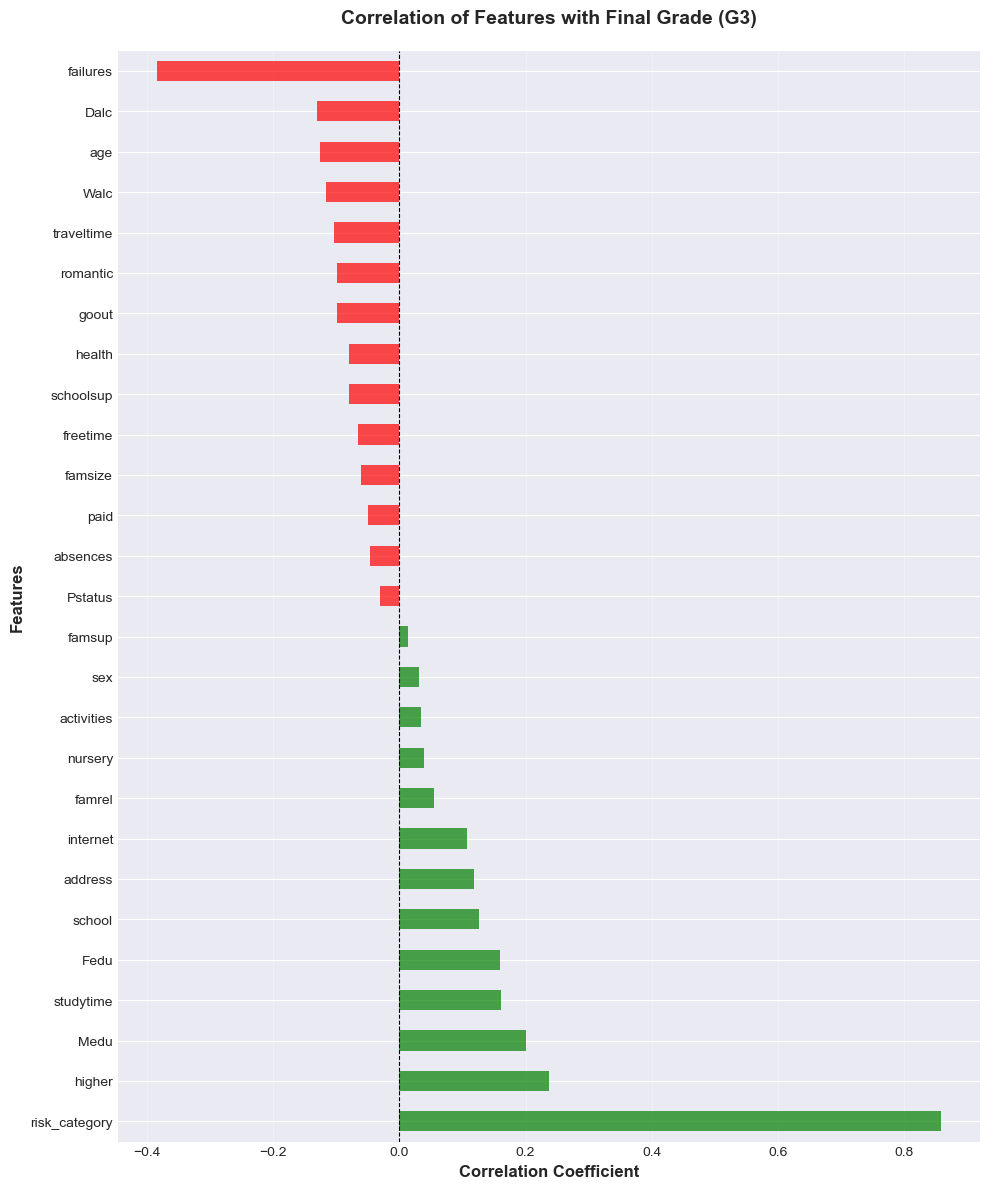

✓ Correlation bar chart created


In [15]:
# Visualize correlations with G3 (bar chart)
plt.figure(figsize=(10, 12))

# Exclude G3 itself and G1, G2 if present (we want to predict WITHOUT prior grades)
corr_to_plot = correlations_with_g3.drop(['G3'], errors='ignore')
if 'G1' in corr_to_plot.index:
    corr_to_plot = corr_to_plot.drop(['G1', 'G2'], errors='ignore')

# Create color map (positive = green, negative = red)
colors = ['green' if x > 0 else 'red' for x in corr_to_plot.values]

corr_to_plot.plot(kind='barh', color=colors, alpha=0.7)
plt.xlabel('Correlation Coefficient', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Correlation of Features with Final Grade (G3)', 
          fontsize=14, fontweight='bold', pad=20)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Correlation bar chart created")

### Top 10 Most Predictive Features

In [16]:
# Get top 10 features (excluding G3, G1, G2)
top_features = correlations_with_g3.drop(['G3'], errors='ignore')
if 'G1' in top_features.index:
    top_features = top_features.drop(['G1', 'G2'], errors='ignore')

# Get top 10 by absolute value
top_10 = top_features.abs().sort_values(ascending=False).head(10)

print("=" * 70)
print("TOP 10 MOST PREDICTIVE FEATURES (by absolute correlation)")
print("=" * 70)
for i, (feature, corr_value) in enumerate(top_features[top_10.index].items(), 1):
    direction = "Positive" if corr_value > 0 else "Negative"
    print(f"{i:2d}. {feature:15s} → {corr_value:+.4f} ({direction})")
print("=" * 70)

TOP 10 MOST PREDICTIVE FEATURES (by absolute correlation)
 1. risk_category   → +0.8576 (Positive)
 2. failures        → -0.3831 (Negative)
 3. higher          → +0.2366 (Positive)
 4. Medu            → +0.2015 (Positive)
 5. studytime       → +0.1616 (Positive)
 6. Fedu            → +0.1598 (Positive)
 7. Dalc            → -0.1296 (Negative)
 8. school          → +0.1271 (Positive)
 9. age             → -0.1253 (Negative)
10. address         → +0.1177 (Positive)


---
## 4. Full Correlation Heatmap

Visualize correlations between ALL numeric features to understand relationships and potential multicollinearity.

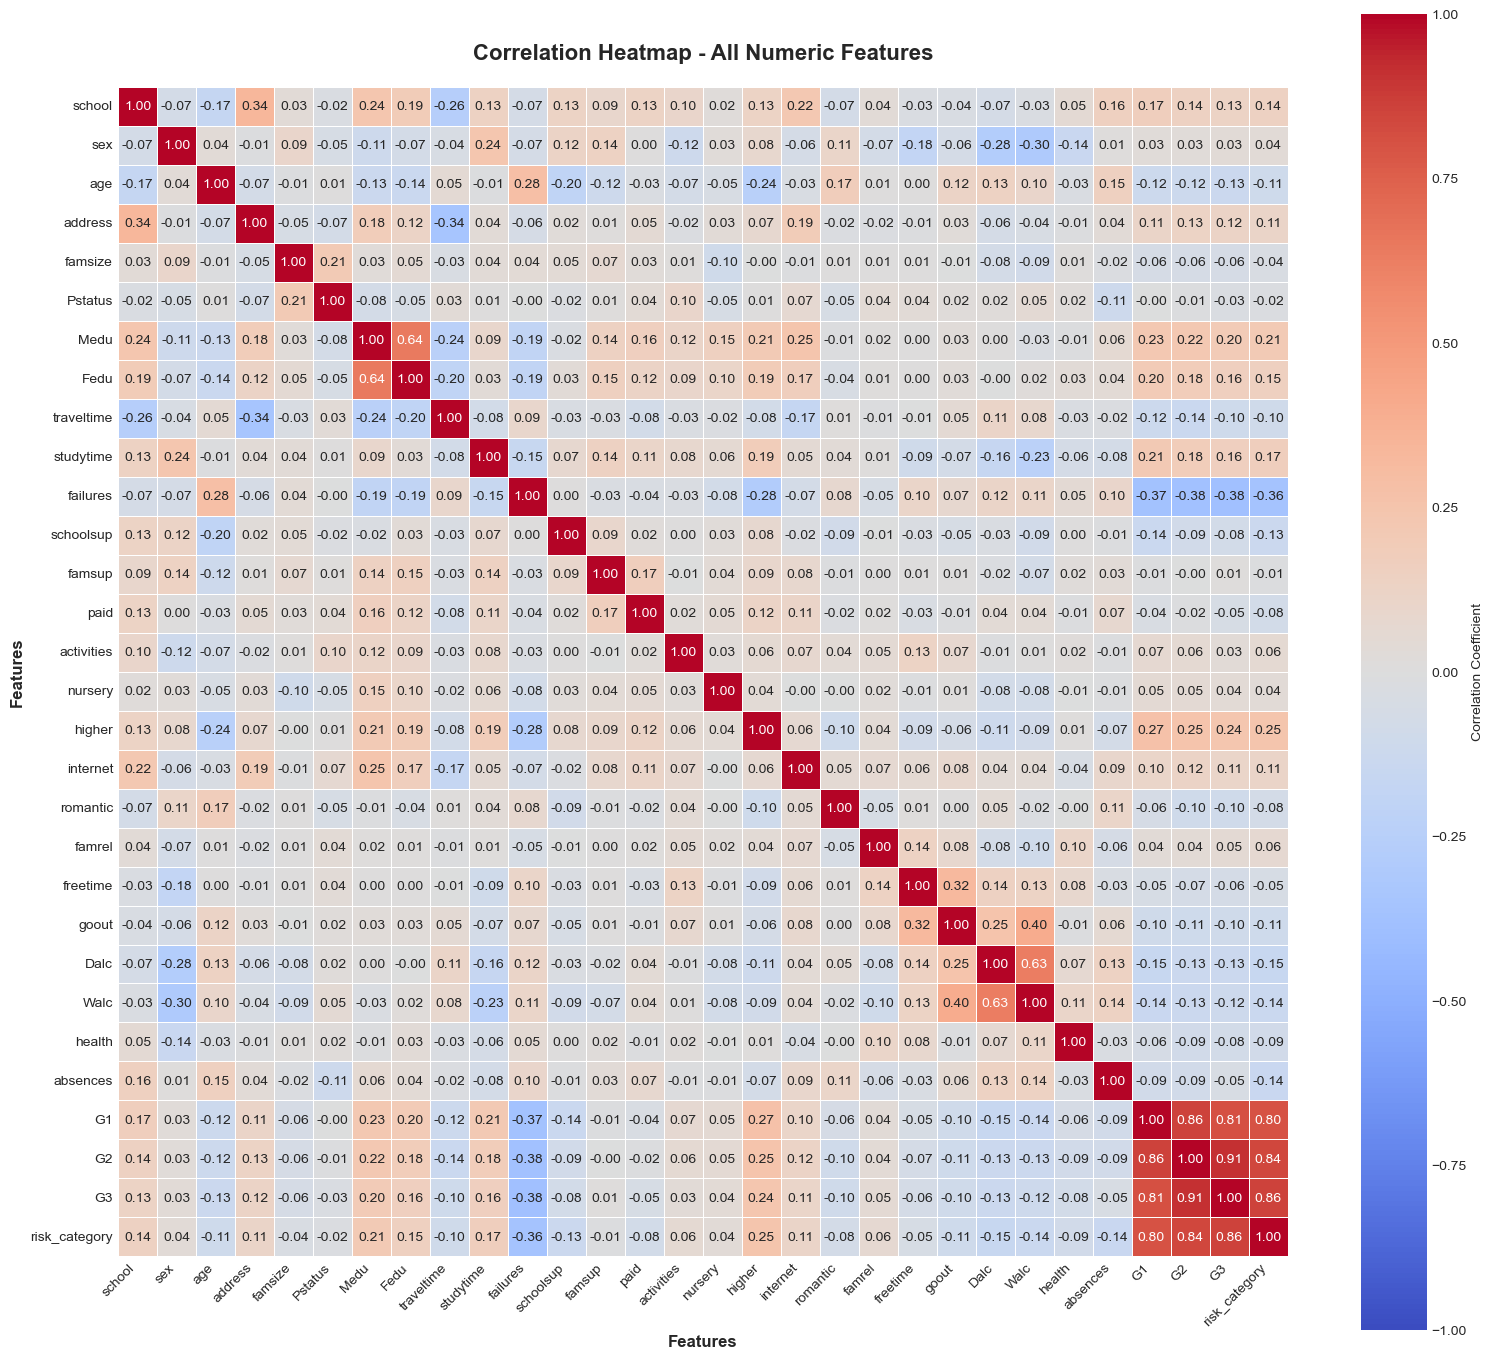

✓ Full correlation heatmap created


In [17]:
# Calculate full correlation matrix
correlation_matrix = df_corr.corr()

# Create heatmap
plt.figure(figsize=(16, 14))

sns.heatmap(correlation_matrix, 
            annot=True,           # Show correlation values
            fmt='.2f',            # 2 decimal places
            cmap='coolwarm',      # Color scheme (red=negative, blue=positive)
            center=0,             # Center colormap at 0
            square=True,          # Square cells
            linewidths=0.5,       # Grid lines
            cbar_kws={'label': 'Correlation Coefficient'},
            vmin=-1, vmax=1)      # Scale from -1 to 1

plt.title('Correlation Heatmap - All Numeric Features', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Features', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("✓ Full correlation heatmap created")

---
## 5. Focused Heatmap: Top Features Only

Create a cleaner heatmap showing only the top predictive features.

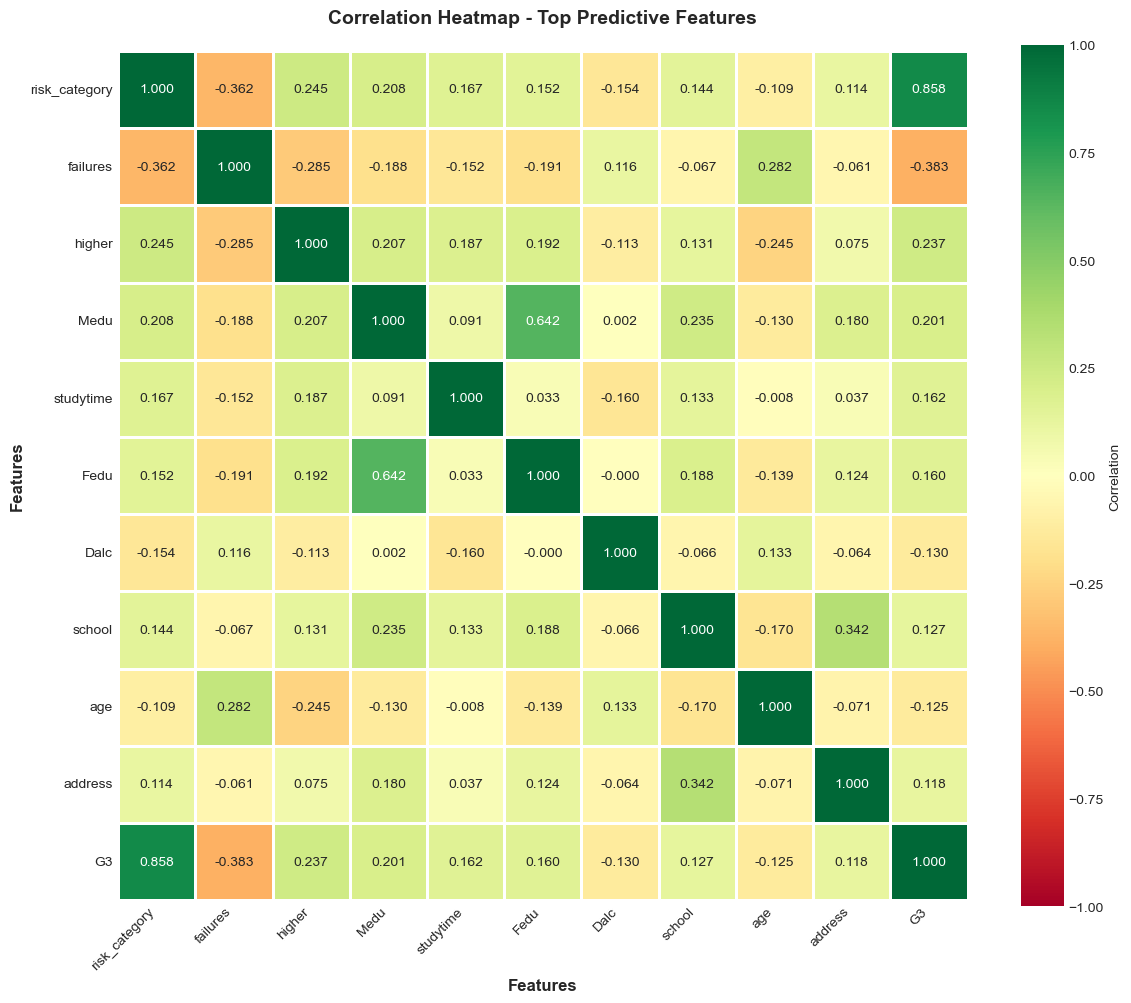

✓ Top features heatmap created


In [18]:
# Select top 15 features (including G3 for reference)
top_15_features = list(top_10.head(15).index) + ['G3']
top_15_features = [f for f in top_15_features if f in df_corr.columns]

# Get correlation matrix for top features only
top_corr_matrix = df_corr[top_15_features].corr()

# Create focused heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(top_corr_matrix,
            annot=True,
            fmt='.3f',
            cmap='RdYlGn',       # Red-Yellow-Green colormap
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={'label': 'Correlation'},
            vmin=-1, vmax=1)

plt.title('Correlation Heatmap - Top Predictive Features', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Features', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("✓ Top features heatmap created")

---
## 6. Multicollinearity Analysis

Check for highly correlated features (multicollinearity) which can cause issues in modeling.

In [19]:
# Find pairs of features with high correlation (|r| > 0.7)
threshold = 0.7

# Get upper triangle of correlation matrix (to avoid duplicates)
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Find high correlations
high_corr_pairs = []
for column in upper_triangle.columns:
    for index in upper_triangle.index:
        corr_value = upper_triangle.loc[index, column]
        if abs(corr_value) > threshold:
            high_corr_pairs.append((index, column, corr_value))

# Display results
print("=" * 70)
print(f"MULTICOLLINEARITY CHECK (|correlation| > {threshold})")
print("=" * 70)

if high_corr_pairs:
    print(f"\nFound {len(high_corr_pairs)} highly correlated feature pairs:\n")
    for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {feat1:15s} ↔ {feat2:15s} : {corr:+.4f}")
    print("\n⚠️  WARNING: High correlation between features may cause multicollinearity.")
    print("   Consider removing one feature from each highly correlated pair.")
else:
    print(f"\n✓ No severe multicollinearity detected (all |r| < {threshold})")
    print("  Features are relatively independent - good for modeling!")

print("=" * 70)

MULTICOLLINEARITY CHECK (|correlation| > 0.7)

Found 6 highly correlated feature pairs:

  G2              ↔ G3              : +0.9107
  G1              ↔ G2              : +0.8587
  G3              ↔ risk_category   : +0.8576
  G2              ↔ risk_category   : +0.8366
  G1              ↔ G3              : +0.8091
  G1              ↔ risk_category   : +0.7970

⚠️  WARNING: High correlation between features may cause multicollinearity.
   Consider removing one feature from each highly correlated pair.


---
## 7. Summary Statistics for Top Features

In [20]:
# Get top 10 feature names
top_10_names = list(top_10.head(10).index)

# Display summary statistics
print("=" * 70)
print("SUMMARY STATISTICS FOR TOP 10 PREDICTIVE FEATURES")
print("=" * 70)
print(df[top_10_names + ['G3']].describe().round(2))
print("=" * 70)

SUMMARY STATISTICS FOR TOP 10 PREDICTIVE FEATURES
       failures     Medu  studytime     Fedu     Dalc      age       G3
count   1044.00  1044.00    1044.00  1044.00  1044.00  1044.00  1044.00
mean       0.26     2.60       1.97     2.39     1.49    16.73    11.34
std        0.66     1.12       0.83     1.10     0.91     1.24     3.86
min        0.00     0.00       1.00     0.00     1.00    15.00     0.00
25%        0.00     2.00       1.00     1.00     1.00    16.00    10.00
50%        0.00     3.00       2.00     2.00     1.00    17.00    11.00
75%        0.00     4.00       2.00     3.00     2.00    18.00    14.00
max        3.00     4.00       4.00     4.00     5.00    22.00    20.00


---
## 8. Key Findings & Insights

### Positive Correlations (Higher → Better Grades)
Based on the analysis above, document which features show positive correlation with G3.

**Expected positive factors:**
- Higher parent education (Medu, Fedu)
- More study time
- School/family support
- Desire for higher education
- Better family relationships

### Negative Correlations (Higher → Lower Grades)
Document features with negative correlation.

**Expected negative factors:**
- Past failures
- More absences
- Higher alcohol consumption
- More time going out
- Longer travel time to school

### Multicollinearity Concerns
Document any features that are highly correlated with each other.

### Recommendations for Modeling
1. **Include these top features** in the model
2. **Remove redundant features** if multicollinearity is severe
3. **Feature engineering opportunities** - combine related features
4. **Feature scaling** - many features have different ranges

---

## 9. Save Results for Documentation

In [21]:
# Save top features to CSV for reference
top_features_df = pd.DataFrame({
    'Feature': correlations_with_g3.index,
    'Correlation_with_G3': correlations_with_g3.values
})

top_features_df = top_features_df[top_features_df['Feature'] != 'G3']
if 'G1' in top_features_df['Feature'].values:
    top_features_df = top_features_df[~top_features_df['Feature'].isin(['G1', 'G2'])]

top_features_df = top_features_df.sort_values('Correlation_with_G3', 
                                               key=abs, 
                                               ascending=False)

# Save to CSV
output_path = '../data/processed/feature_correlations.csv'
top_features_df.to_csv(output_path, index=False)

print(f"✓ Feature correlations saved to: {output_path}")
print(f"\nTop 10 features saved for model development in Week 5!")

✓ Feature correlations saved to: ../data/processed/feature_correlations.csv

Top 10 features saved for model development in Week 5!


---
## 10. Conclusion

### Analysis Complete! ✅

**What we learned:**
1. Identified the top 10 most predictive features for student performance
2. Visualized correlations using multiple heatmaps
3. Checked for multicollinearity issues
4. Saved results for Week 5 modeling

**Next Steps:**
- Emmanuel: Study habits analysis
- Yugant: Family background analysis  
- Hamza: Social/behavioral analysis
- Week 4: Feature engineering based on these correlations

---
**Author:** Pratik  
**Week:** 3 (Deep EDA & Correlation Analysis)  
**Status:** ✅ Complete